# Part 5.1 | Categorical Controls

This notebook generates figures for the Part 5.1 concept slides.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent styling
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 14

## Simpson's Paradox: Hospital Survival Rates

This example demonstrates how aggregated data can lead to misleading conclusions.

In [2]:
# Load the hospital data
hospital = pd.read_csv('../../../econ-0150/data/Hospital_Survival.csv')
hospital

,Hospital,Severity,Patients,Survived
0,A,Mild,800,760
1,A,Severe,200,100
2,B,Mild,200,196
3,B,Severe,800,480


In [3]:
# Calculate survival rates
hospital['Survival_Rate'] = hospital['Survived'] / hospital['Patients'] * 100

# Aggregate by hospital
agg = hospital.groupby('Hospital').agg({
    'Patients': 'sum',
    'Survived': 'sum'
}).reset_index()
agg['Overall_Rate'] = agg['Survived'] / agg['Patients'] * 100
agg

,Hospital,Patients,Survived,Overall_Rate
0,A,1000,860,86.0
1,B,1000,676,67.6


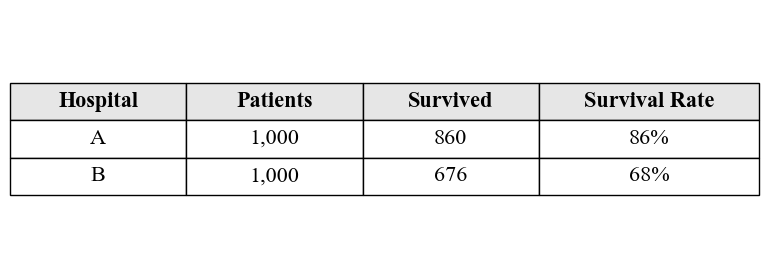

In [4]:
# Figure s_01: Aggregated summary table
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

# Create table data
table_data = [
    ['Hospital', 'Patients', 'Survived', 'Survival Rate'],
    ['A', '1,000', '860', '86%'],
    ['B', '1,000', '676', '68%']
]

table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.2, 0.2, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1.5, 2)

# Style header row
for j in range(4):
    table[(0, j)].set_facecolor('#E6E6E6')
    table[(0, j)].set_text_props(weight='bold')

plt.tight_layout()
plt.savefig('i/s_01.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

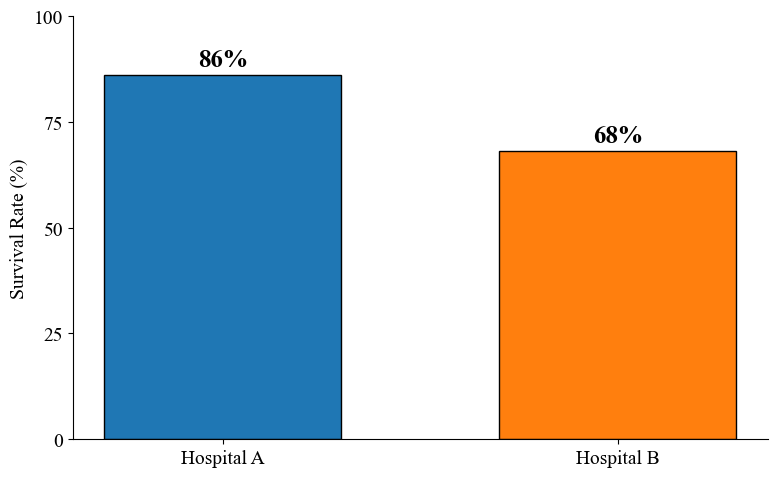

In [5]:
# Figure s_02: Bar chart of overall survival rates
fig, ax = plt.subplots(figsize=(8, 5))

hospitals = ['Hospital A', 'Hospital B']
rates = [86, 68]
colors = ['C0', 'C1']

bars = ax.bar(hospitals, rates, color=colors, width=0.6, edgecolor='black', linewidth=1)

# Add value labels
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate}%', ha='center', va='bottom', fontsize=18, fontweight='bold')

ax.set_ylabel('Survival Rate (%)', fontsize=14)
ax.set_ylim(0, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('i/s_02.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

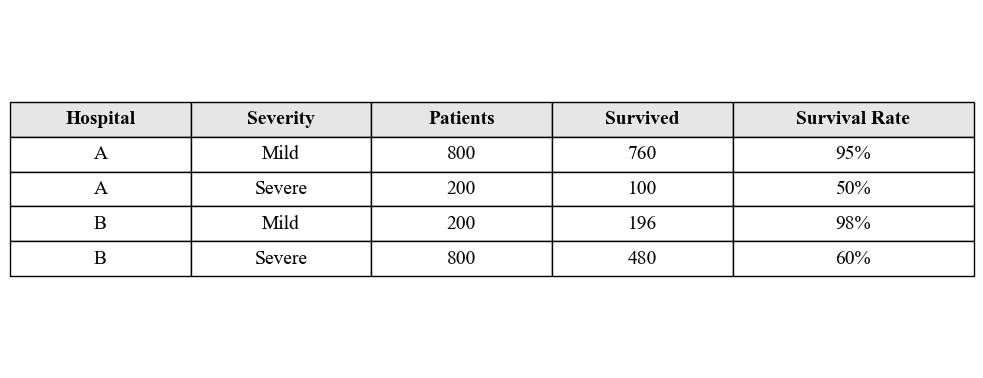

In [6]:
# Figure s_03: Detailed table with severity breakdown
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# Create table data with severity breakdown
table_data = [
    ['Hospital', 'Severity', 'Patients', 'Survived', 'Survival Rate'],
    ['A', 'Mild', '800', '760', '95%'],
    ['A', 'Severe', '200', '100', '50%'],
    ['B', 'Mild', '200', '196', '98%'],
    ['B', 'Severe', '800', '480', '60%']
]

table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.15, 0.15, 0.15, 0.15, 0.2]
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.5, 1.8)

# Style header row
for j in range(5):
    table[(0, j)].set_facecolor('#E6E6E6')
    table[(0, j)].set_text_props(weight='bold')

plt.tight_layout()
plt.savefig('i/s_03.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

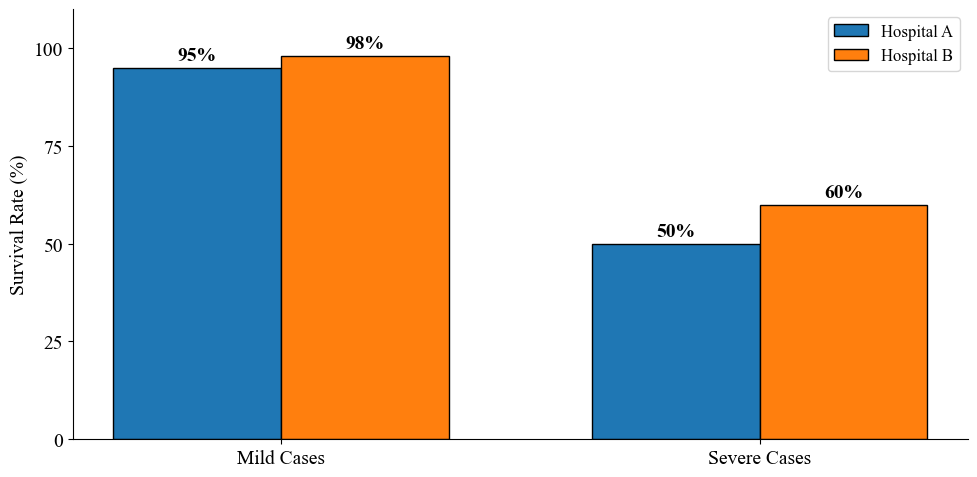

In [7]:
# Figure s_04: Grouped bar chart by severity
fig, ax = plt.subplots(figsize=(10, 5))

severities = ['Mild Cases', 'Severe Cases']
x = np.arange(len(severities))
width = 0.35

# Survival rates by severity
hosp_a_rates = [95, 50]  # Mild, Severe
hosp_b_rates = [98, 60]  # Mild, Severe

bars_a = ax.bar(x - width/2, hosp_a_rates, width, label='Hospital A', color='C0', edgecolor='black', linewidth=1)
bars_b = ax.bar(x + width/2, hosp_b_rates, width, label='Hospital B', color='C1', edgecolor='black', linewidth=1)

# Add value labels
for bars in [bars_a, bars_b]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{int(bar.get_height())}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Survival Rate (%)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(severities, fontsize=14)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.legend(fontsize=12, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('i/s_04.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

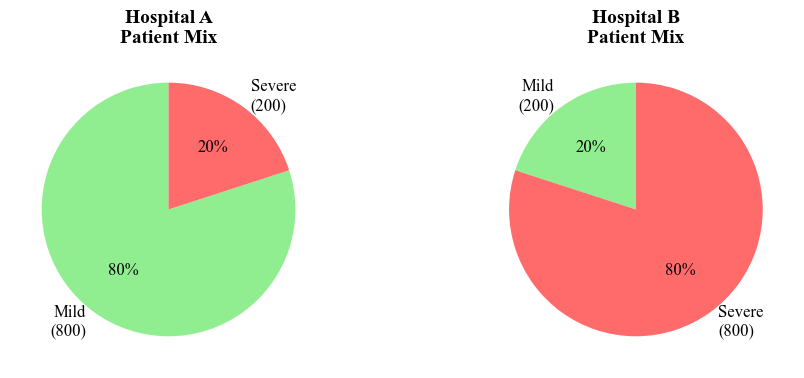

In [8]:
# Figure s_05: Patient distribution by severity (showing the confounder)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Hospital A: mostly mild
ax1 = axes[0]
sizes_a = [800, 200]
colors_a = ['#90EE90', '#FF6B6B']  # light green for mild, light red for severe
ax1.pie(sizes_a, labels=['Mild\n(800)', 'Severe\n(200)'], colors=colors_a, 
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12})
ax1.set_title('Hospital A\nPatient Mix', fontsize=14, fontweight='bold')

# Hospital B: mostly severe
ax2 = axes[1]
sizes_b = [200, 800]
colors_b = ['#90EE90', '#FF6B6B']
ax2.pie(sizes_b, labels=['Mild\n(200)', 'Severe\n(800)'], colors=colors_b, 
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12})
ax2.set_title('Hospital B\nPatient Mix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('i/s_05.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

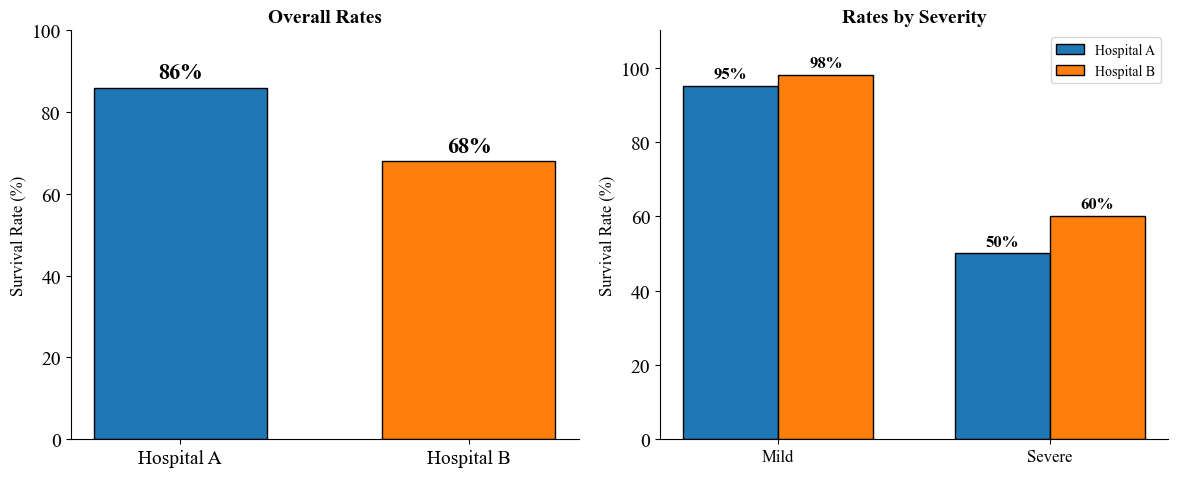

In [9]:
# Figure s_06: Summary comparison - overall vs within-group
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Overall (misleading)
ax1 = axes[0]
hospitals = ['Hospital A', 'Hospital B']
overall_rates = [86, 68]
bars1 = ax1.bar(hospitals, overall_rates, color=['C0', 'C1'], width=0.6, edgecolor='black', linewidth=1)
for bar, rate in zip(bars1, overall_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate}%', ha='center', va='bottom', fontsize=16, fontweight='bold')
ax1.set_ylabel('Survival Rate (%)', fontsize=12)
ax1.set_ylim(0, 100)
ax1.set_title('Overall Rates', fontsize=14, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: By severity (truth)
ax2 = axes[1]
x = np.arange(2)
width = 0.35
hosp_a_rates = [95, 50]
hosp_b_rates = [98, 60]
bars_a = ax2.bar(x - width/2, hosp_a_rates, width, label='Hospital A', color='C0', edgecolor='black', linewidth=1)
bars_b = ax2.bar(x + width/2, hosp_b_rates, width, label='Hospital B', color='C1', edgecolor='black', linewidth=1)
for bars in [bars_a, bars_b]:
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{int(bar.get_height())}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Survival Rate (%)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['Mild', 'Severe'], fontsize=12)
ax2.set_ylim(0, 110)
ax2.set_title('Rates by Severity', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('i/s_06.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()